In [383]:
import matrix_mul_for_linear_reg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import os
path = os.getcwd() + '/ex2data1.txt'
data = pd.read_csv(path, header=None, names=['Exam 1', 'Exam 2', 'Admitted'])

In [384]:
X = data.values[:, :2].T
y = data.values[:, 2:].T
theta = np.zeros((X.shape[0]+1, 1))
X = np.concatenate([np.ones([1, X.shape[1]]), X])
for i in range(1, X.shape[0]):
    X[i, :] = (X[i, :] - np.mean(X[i, :])) / (np.std(X[i, :]))


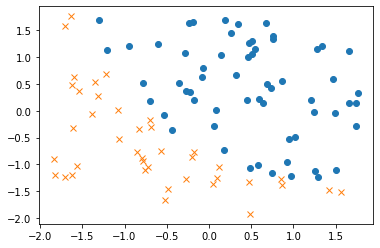

In [385]:
plt.figure()
X1_1 = X[1, y[0, :] == 1.0]
X2_1 = X[2, y[0, :] == 1.0]
X1_0 = X[1, y[0, :] == 0.0]
X2_0 = X[2, y[0, :] == 0.0]
plt.plot(X1_1, X2_1, 'o')
plt.plot(X1_0, X2_0, 'x')
plt.show()

4

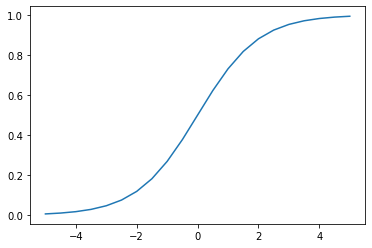

In [386]:
def sig(t):
    return 1/(1+np.exp(-t))

ar=np.linspace(-5,5,21)
plt.plot(ar,sig(ar))

5

In [404]:
def h(theta,X):
    return sig(theta.transpose()@X)

def cost(theta, X, y):
    a=h(theta,X)
    plus=y@np.log(a.transpose())
    minus=(1-y)@np.log((1-a.transpose()))
    return (-plus-minus)/(len(y[0]))

In [388]:
theta = np.zeros((X.shape[0], 1))


In [389]:
#a=sig(h(theta,X))
print(cost(theta, X, y))


[[0.69314718]]


6

In [390]:
def simple_gradient(X, y, theta, alpha, it):
    Tcost=[cost(theta, X, y)]
    hTheta=theta
    for i in range(it):
        amount=len(y[0])
        '''core of function'''
        hTheta-=alpha*((h(theta,X)-y)@X.transpose()/amount).transpose()
        Tcost.append(cost(theta, X, y))
        if Tcost[-1]>Tcost[-2]:
            break
        else:
            theta=hTheta
 
    return theta, np.array(Tcost)

In [391]:
theta = np.zeros((X.shape[0], 1))
alpha = 1
it=150
ntheta,cost=simple_gradient(X, y, theta, alpha, it)
print(ntheta,cost[-1])


[[1.41957362]
 [3.35941597]
 [3.11271333]] [[0.20640714]]


7

In [426]:
#accuracy
s=h(ntheta,X)
predicted=0
for i in range(len(y[0])):
    if s[0][i]>=0.5 and  y[0][i]==1:
        predicted+=1
    elif s[0][i]<0.5 and  y[0][i]==0:
        predicted+=1
print(predicted/len(y[0]))

0.89


8

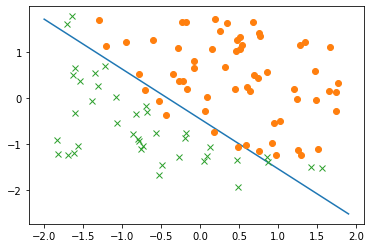

In [393]:
x1 = np.arange(-2.0, 2.0, 0.1)
x2 = -ntheta[0, 0]/ntheta[2, 0] - ntheta[1, 0]/ntheta[2, 0] * x1
plt.plot(x1, x2)
X1_1 = X[1, y[0, :] == 1.0]
X2_1 = X[2, y[0, :] == 1.0]
X1_0 = X[1, y[0, :] == 0.0]
X2_0 = X[2, y[0, :] == 0.0]
plt.plot(X1_1, X2_1, 'o')
plt.plot(X1_0, X2_0, 'x')
plt.show()

In [394]:
def computeCost(X, y, theta):
    a=(theta.transpose()@X-y)**2
    return np.sum(a)/(2*len(y[0]))

In [395]:
def simple_gradient(X, y, theta, alpha, it):
    cost=[computeCost(X,y,theta)]
    hTheta=theta
    for i in range(it):
        '''     hTheta[0]-=alpha*np.sum((hTheta.transpose()@X-y))/len(y[0])'''
        '''hTheta[0]-=alpha*(hTheta.transpose()@X-y)@X[0]/len(y[0])'''
        amount=len(y[0])
        hTheta-=alpha*((theta.transpose()@X-y)@X.transpose()/amount).transpose()
        cost.append(computeCost(X,y,hTheta))
        if cost[-1]>cost[-2]:
            break
        else:
            theta=hTheta
 
    return theta, np.array(cost)

SKLEARN

In [396]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
 
iris = datasets.load_iris()
Xi = iris.data[:, :2]  # we are analyzing only 2 parameters
Y = iris.target

In [397]:
regr = LogisticRegression()
 
# Learning model on training data
regr.fit(Xi,Y)
# Predicting values using test data
Y_predicted = regr.predict(Xi[:2, :])
 
# Regression coefficients (theta)
print('Coefficients: \n', regr.coef_,regr.intercept_)
 
#  Residual sum of squares error
#error = np.mean((regr.predict(X_test.reshape(-1, 1)) - Y_test.reshape(-1, 1)) ** 2)
#print("Residual sum of squares: {}".format(error))

Coefficients: 
 [[-2.70890249  2.32402378]
 [ 0.61273259 -1.57058803]
 [ 2.0961699  -0.75343574]] [ 7.91322129  1.84504714 -9.75826843]


<ipython-input-398-8c29e2daed34>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)


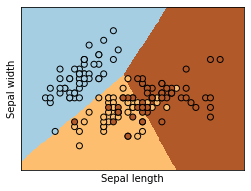

In [398]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = Xi[:, 0].min() - .5, Xi[:, 0].max() + .5
y_min, y_max = Xi[:, 1].min() - .5, Xi[:, 1].max() + .5
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = regr.predict(np.c_[xx.ravel(), yy.ravel()])
 
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1, figsize=(4, 3))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)
 
# Plot also the training points
plt.scatter(Xi[:, 0], Xi[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
 
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
 
plt.show()

In [429]:
regr.predict_proba(Xi)

array([[9.23473153e-01, 5.85080967e-02, 1.80187501e-02],
       [7.91565001e-01, 1.80912648e-01, 2.75223510e-02],
       [9.42364041e-01, 5.08634498e-02, 6.77250960e-03],
       [9.40553540e-01, 5.37594346e-02, 5.68702546e-03],
       [9.61853130e-01, 2.96143932e-02, 8.53247725e-03],
       [9.43195775e-01, 3.40879207e-02, 2.27163048e-02],
       [9.80228540e-01, 1.74171057e-02, 2.35435467e-03],
       [9.22927337e-01, 6.19217567e-02, 1.51509067e-02],
       [9.35998984e-01, 5.99949470e-02, 4.00606950e-03],
       [8.47181712e-01, 1.31165035e-01, 2.16532530e-02],
       [8.90214168e-01, 7.01091740e-02, 3.96766576e-02],
       [9.60793368e-01, 3.31735691e-02, 6.03306252e-03],
       [8.43554938e-01, 1.38305338e-01, 1.81397240e-02],
       [9.67965497e-01, 3.01509884e-02, 1.88351450e-03],
       [8.24095093e-01, 7.61837358e-02, 9.97211711e-02],
       [9.65419483e-01, 1.34828235e-02, 2.10976937e-02],
       [9.43195775e-01, 3.40879207e-02, 2.27163048e-02],
       [9.23473153e-01, 5.85080